# Predict whether a diabetic patient will be readmitted to hospital within 30 days of discharge

## KEY EDA FINDINGS
### 1. Most patients are in the age range of 70-80
### 2. Number of medications distribution is right skewed- longer tail on right side
### 3. Atleast half of the patients do not have any procedures done
### 4. Note: weight, medical_specialty, payer_code have highest amount of missing data(which is present as ? in data)
### 5. 30-day readmission rate is relatively consistent across age groups (roughly 10-12%), suggesting age alone is not a strong predictor
### 6. Target variable is imbalanced — only 11% of patients were readmitted within 30 days. Will need to account for this during modeling

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("diabetic_data.csv")

In [3]:
admission_map = pd.read_csv("IDS_mapping.csv")

In [4]:
admission_map.head()

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available


# EDA

In [5]:
print(df.shape)
print(df.head())

(101766, 50)
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No        

In [6]:
print(df.columns)

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')


In [7]:
print(df.dtypes)

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

In [8]:
print(df.isnull().sum())

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
weight                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazo

In [9]:
(df == "?").sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum                   0
A1Cresult                       0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [10]:
print(df["readmitted"].value_counts())  # Dependent variable

NO     54864
>30    35545
<30    11357
Name: readmitted, dtype: int64


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

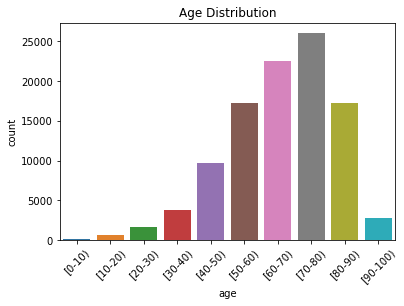

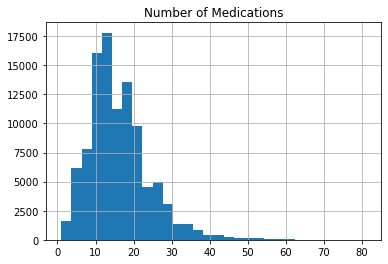

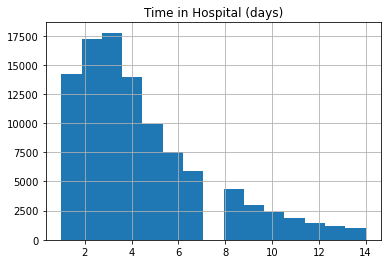

In [12]:
# Individual plots
# Age distribution
sns.countplot(data=df, x="age")
plt.xticks(rotation=45)
plt.title("Age Distribution")
plt.show()

# Number of medications
df["num_medications"].hist(bins=30)
plt.title("Number of Medications")
plt.show()

# Time in hospital
df["time_in_hospital"].hist(bins=15)
plt.title("Time in Hospital (days)")
plt.show()

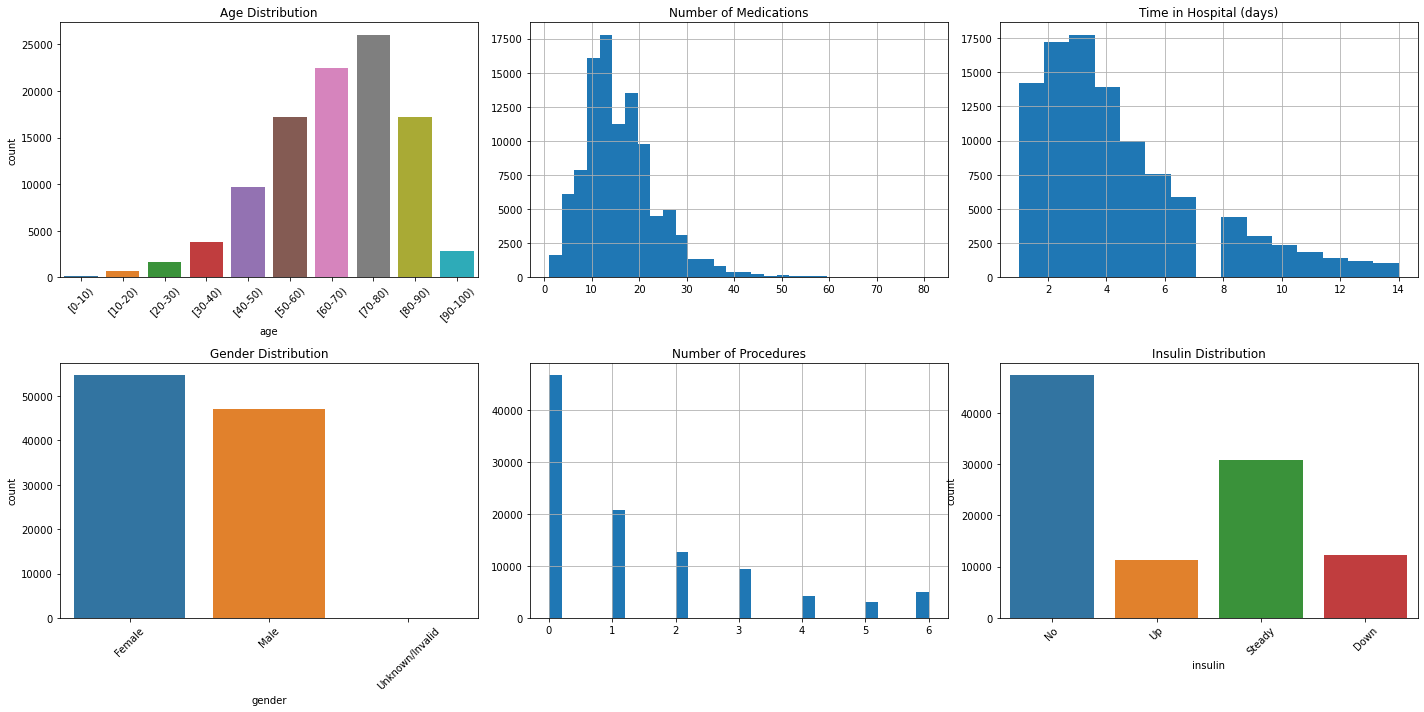

In [13]:
# Grid plots- side by side
fig, axes = plt.subplots(2, 3, figsize=(20, 10))  # 2 rows, 3 columns

# Plot 1
sns.countplot(data = df, x="age", ax=axes[0][0])
axes[0][0].set_title("Age Distribution")
axes[0][0].tick_params(axis='x', rotation=45)

# Plot 2
df["num_medications"].hist(bins=30, ax=axes[0][1])
axes[0][1].set_title("Number of Medications")

# Plot 3
df["time_in_hospital"].hist(bins=15, ax=axes[0][2])
axes[0][2].set_title("Time in Hospital (days)")

# Plot 4
sns.countplot(data = df, x="gender", ax=axes[1][0])
axes[1][0].set_title("Gender Distribution")
axes[1][0].tick_params(axis='x', rotation=45)


# Plot 5
df["num_procedures"].hist(bins=30, ax=axes[1][1])
axes[1][1].set_title("Number of Procedures")
plt.tight_layout()

# Plot 6
sns.countplot(data = df, x="insulin", ax=axes[1][2])
axes[1][2].set_title("Insulin Distribution")
axes[1][2].tick_params(axis='x', rotation=45)

plt.show()

## Observations
### 1. Most patients are in the age range of 70-80
### 2. Number of medications distribution is right skewed- longer tail on right side
### 3. Most patients spend less than 6 days in hospital
### 4. Females are more compared to Males
### 5. Atleast half of the patients do not have any procedures done
### 6. No insulin or steady insulin is given for most of the patients

In [14]:
missing_df = (df== "?").sum()
missing_df = (missing_df/len(df))*100
print(missing_df[missing_df > 0].sort_values(ascending = False))

weight               96.858479
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64


### Note: weight, medical_specialty, payer_code have highest amount of missing data(which is present as ? in data)

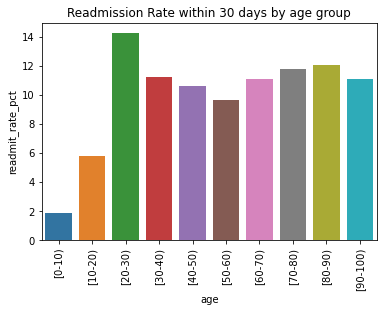

In [15]:
readmit_by_age = df.groupby("age")["readmitted"].apply(lambda x:(x=="<30").mean()*100).reset_index()
readmit_by_age.columns = ("age", "readmit_rate_pct")
sns.barplot(data = readmit_by_age, x="age", y="readmit_rate_pct")
plt.title("Readmission Rate within 30 days by age group")
plt.xticks(rotation=90)
plt.show()

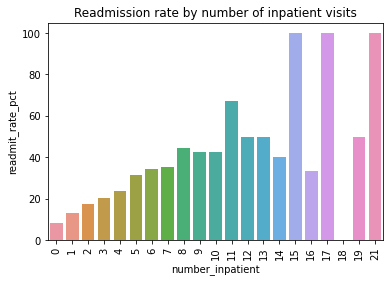

In [16]:
readmit_by_inpatient = df.groupby("number_inpatient")["readmitted"].apply(lambda x:(x=="<30").mean()*100).reset_index()
readmit_by_inpatient.columns = ("number_inpatient", "readmit_rate_pct")
sns.barplot(data = readmit_by_inpatient, x= "number_inpatient", y= "readmit_rate_pct")
plt.title("Readmission rate by number of inpatient visits")
plt.xticks(rotation = 90)
plt.show()

## More prior visits much likely to be readmitted

In [17]:
## Remove variables with high ? values
df= df.drop(columns = ["weight", "medical_specialty", "payer_code"]).copy()

In [18]:
df = df.replace("?", np.nan).copy()

In [19]:
print(df.isnull().sum()[df.isnull().sum()>0])

race      2273
diag_1      21
diag_2     358
diag_3    1423
dtype: int64


In [20]:
df["race"] = df["race"].fillna("Unknown")

In [21]:
df = df.dropna(subset = ["diag_1", "diag_2", "diag_3"]).copy()

In [22]:
df = df.drop(columns=["encounter_id", "patient_nbr"]).copy()

In [23]:
df["readmitted_binary"] = (df["readmitted"] == "<30").astype(int)
print(df["readmitted_binary"].value_counts())

0    88994
1    11250
Name: readmitted_binary, dtype: int64


In [24]:
df["total_services"] = (df["num_lab_procedures"]+df["num_procedures"]+df["number_diagnoses"]+df["num_medications"])

In [25]:
print(df.groupby("readmitted")["total_services"].mean())

readmitted
<30    70.240444
>30    69.188980
NO     67.013229
Name: total_services, dtype: float64


In [ ]:
# Bar chart answer: "what predicts readmission specifically?"
numeric_cols = df.select_dtypes(include="number").columns.tolist()
corr_with_target = df[numeric_cols].corr()["readmitted_binary"].drop("readmitted_binary").sort_values()

plt.figure(figsize=(10, 8))
corr_with_target.plot(kind="barh", color=["red" if x < 0 else "steelblue" for x in corr_with_target])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlation of Features with 30-day Readmission")
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

In [ ]:
# Heatmap answer:  "how does everything relate to everything?"
plt.figure(figsize=(14, 10))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.show()

In [26]:
df.to_csv("diabetic_data_cleaned.csv", index=False)
print("Cleaned data:", df.shape)

Cleaned data: (100244, 47)


## Summary - 06/11
### Columns dropped and why - "encounter_id", "patient_nbr", "weight", "medical_specialty", "payer_code" are dropped
### How missing values were handled - Parameters with high amount of missing values are dropped like weight", "medical_specialty", "payer_code" and parameter "race" with less amount of missing data(indicated as ?) is replaced with null values, and for some parameters like diag_1, diag_2, diag_3 - missing values are dropped
### New features engineered - readmitted_binary - to convert readmitted parameter into binary data(1 if <30 and 0 for others), total_services new parameter added by adding few other parameters
### Final shape of the cleaned dataset- 100244 * 47